Program started
Dataset loaded: (4601, 58)

CLASSIFICATION REPORT (MANUAL)
---------------------------------------------
Class		Precision	Recall		F1
Not Spam	0.90		0.95		0.92
Spam		0.91		0.84		0.87
---------------------------------------------
Accuracy: 90.45%

Confusion Matrix:
 [[533  29]
 [ 59 300]]


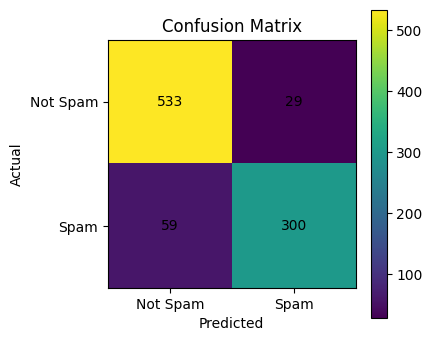

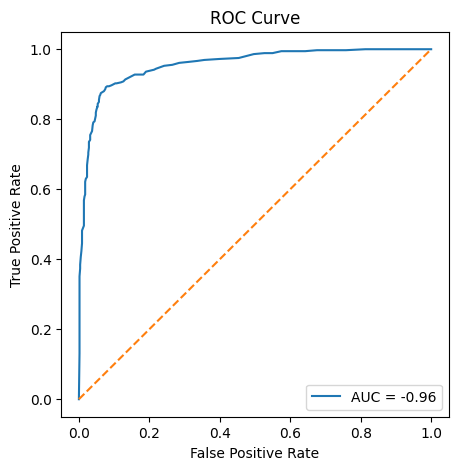

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== DATA SPLIT =====================
def train_test_split_manual(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    idx = np.arange(len(X))
    np.random.shuffle(idx)

    split = int(len(X) * (1 - test_size))
    train_idx = idx[:split]
    test_idx = idx[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# ===================== SCALING =====================
def standard_scaler_fit_transform(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1
    return (X - mean) / std, mean, std

def standard_scaler_transform(X, mean, std):
    return (X - mean) / std

# ===================== LOGISTIC REGRESSION =====================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    for _ in range(epochs):
        linear = np.dot(X, w) + b
        y_pred = sigmoid(linear)

        dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
        db = (1/n_samples) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

    return w, b

def predict_proba(X, w, b):
    return sigmoid(np.dot(X, w) + b)

def predict(X, w, b):
    return (predict_proba(X, w, b) >= 0.5).astype(int)

# ===================== CONFUSION MATRIX =====================
def confusion_matrix_manual(y_true, y_pred):
    cm = np.zeros((2,2), dtype=int)

    for i in range(len(y_true)):
        if y_true[i] == 0 and y_pred[i] == 0:
            cm[0,0] += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            cm[0,1] += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            cm[1,0] += 1
        else:
            cm[1,1] += 1

    return cm

# ===================== CLASSIFICATION REPORT =====================
def classification_report_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    TN, FP = cm[0]
    FN, TP = cm[1]

    precision_spam = TP / (TP + FP) if TP + FP else 0
    recall_spam = TP / (TP + FN) if TP + FN else 0
    f1_spam = 2 * precision_spam * recall_spam / (precision_spam + recall_spam) if precision_spam + recall_spam else 0

    precision_not = TN / (TN + FN) if TN + FN else 0
    recall_not = TN / (TN + FP) if TN + FP else 0
    f1_not = 2 * precision_not * recall_not / (precision_not + recall_not) if precision_not + recall_not else 0

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    print("\nCLASSIFICATION REPORT (MANUAL)")
    print("---------------------------------------------")
    print("Class\t\tPrecision\tRecall\t\tF1")
    print(f"Not Spam\t{precision_not:.2f}\t\t{recall_not:.2f}\t\t{f1_not:.2f}")
    print(f"Spam\t\t{precision_spam:.2f}\t\t{recall_spam:.2f}\t\t{f1_spam:.2f}")
    print("---------------------------------------------")
    print(f"Accuracy: {accuracy*100:.2f}%")

    return cm

# ===================== ROC CURVE =====================
def roc_curve_manual(y_true, y_scores, steps=100):
    tpr = []
    fpr = []

    for thresh in np.linspace(0, 1, steps):
        y_pred = (y_scores >= thresh).astype(int)
        cm = confusion_matrix_manual(y_true, y_pred)
        TN, FP = cm[0]
        FN, TP = cm[1]

        TPR = TP / (TP + FN) if TP + FN else 0
        FPR = FP / (FP + TN) if FP + TN else 0

        tpr.append(TPR)
        fpr.append(FPR)

    return np.array(fpr), np.array(tpr)

def auc_manual(fpr, tpr):
    return np.trapz(tpr, fpr)

# ===================== PLOTS =====================
def plot_confusion_matrix(cm):
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0,1], ["Not Spam","Spam"])
    plt.yticks([0,1], ["Not Spam","Spam"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.colorbar()
    plt.show()

def plot_roc_curve(fpr, tpr, auc):
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# ===================== MAIN =====================
def main():
    print("Program started")

    columns = [f"feature_{i}" for i in range(57)] + ["label"]
    data = pd.read_csv("../Lab_5_14012026/spambase.data", header=None, names=columns)
    print("Dataset loaded:", data.shape)

    X = data.drop("label", axis=1).values
    y = data["label"].values

    X_train, X_test, y_train, y_test = train_test_split_manual(X, y)

    X_train, mean, std = standard_scaler_fit_transform(X_train)
    X_test = standard_scaler_transform(X_test, mean, std)

    w, b = train_logistic_regression(X_train, y_train)

    y_scores = predict_proba(X_test, w, b)
    y_pred = predict(X_test, w, b)

    cm = classification_report_manual(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)
    plot_confusion_matrix(cm)

    fpr, tpr = roc_curve_manual(y_test, y_scores)
    auc = auc_manual(fpr, tpr)
    plot_roc_curve(fpr, tpr, auc)

# ===================== RUN =====================
main()